# US Accidents ML Model
## Authors: Austin McCutcheon Trevor Schmuckley
## Date Due: 04/12

### Summary:
We used data from the link below to build an ML model that would predict US accidents

https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents


ID
Source
*Severity
*Start_Time
*End_Time
*Start_Lat
*Start_Lng
End_Lat
End_Lng
Distance(mi)
Description
*Street
*City
*County
*State
*Zipcode
*Country
Timezone
Airport_Code
-*Weather_Timestamp
*Temperature(F)
*Wind_Chill(F)
*Humidity(%)
*Pressure(in)
*Visibility(mi)
Wind_Direction
*Wind_Speed(mph)
*Precipitation(in)
-*Weather_Condition

(Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight)

In [4]:
import sklearn as skl
import numpy as np
from lark.parsers.earley_forest import ForestNode
import os
import pandas as pd
import kagglehub
# other imports

In [5]:
# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print("Dataset folder:", path)

# See what files are inside
print(os.listdir(path))

Dataset folder: /Users/trevorschmuckley/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13
['US_Accidents_March23.csv']


In [6]:
csv_path = os.path.join(path, "US_Accidents_March23.csv")

cols = [
    "Severity",
    "Start_Time",
    "End_Time",
    "Start_Lat",
    "Start_Lng",
    "Street",
    "City",
    "County",
    "State",
    "Zipcode",
    "Country",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

df = pd.read_csv(csv_path, usecols=cols)
print(df.head())

   Severity           Start_Time             End_Time  Start_Lat  Start_Lng  \
0         3  2016-02-08 05:46:00  2016-02-08 11:00:00  39.865147 -84.058723   
1         2  2016-02-08 06:07:59  2016-02-08 06:37:59  39.928059 -82.831184   
2         2  2016-02-08 06:49:27  2016-02-08 07:19:27  39.063148 -84.032608   
3         3  2016-02-08 07:23:34  2016-02-08 07:53:34  39.747753 -84.205582   
4         2  2016-02-08 07:39:07  2016-02-08 08:09:07  39.627781 -84.188354   

                      Street          City      County State     Zipcode  \
0                     I-70 E        Dayton  Montgomery    OH       45424   
1                   Brice Rd  Reynoldsburg    Franklin    OH  43068-3402   
2             State Route 32  Williamsburg    Clermont    OH       45176   
3                     I-75 S        Dayton  Montgomery    OH       45417   
4  Miamisburg Centerville Rd        Dayton  Montgomery    OH       45459   

  Country  Temperature(F)  Wind_Chill(F)  Humidity(%)  Pressure(in) 

In [7]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(7728394, 18)
Severity               int64
Start_Time            object
End_Time              object
Start_Lat            float64
Start_Lng            float64
Street                object
City                  object
County                object
State                 object
Zipcode               object
Country               object
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
dtype: object
Severity                   0
Start_Time                 0
End_Time                   0
Start_Lat                  0
Start_Lng                  0
Street                 10869
City                     253
County                     0
State                      0
Zipcode                 1915
Country                    0
Temperature(F)        163853
Wind_Chill(F)        1999019
Humidity(%)           174144
Pressure(in)          140679
Visibility(mi) 

In [8]:
## Removing NaN:
df = df.dropna(axis=0, how= 'any')
print(df.head(10))

    Severity           Start_Time             End_Time  Start_Lat  Start_Lng  \
5          3  2016-02-08 07:44:26  2016-02-08 08:14:26  40.100590 -82.925194   
9          3  2016-02-08 08:10:04  2016-02-08 08:40:04  40.100590 -82.925194   
11         3  2016-02-08 08:21:27  2016-02-08 08:51:27  39.932709 -82.830910   
14         2  2016-02-08 08:39:43  2016-02-08 09:09:43  39.972038 -82.913521   
20         2  2016-02-08 10:11:15  2016-02-08 10:41:15  40.052509 -82.882332   
22         2  2016-02-08 11:53:19  2016-02-08 12:23:19  39.628288 -84.226151   
23         3  2016-02-08 12:00:00  2016-02-08 12:45:00  40.023487 -82.994888   
25         2  2016-02-08 12:41:08  2016-02-08 13:11:08  40.158024 -82.641762   
26         2  2016-02-08 12:52:05  2016-02-08 13:37:05  39.733219 -84.159653   
27         2  2016-02-08 14:24:48  2016-02-08 15:09:48  39.775303 -84.200523   

               Street          City      County State     Zipcode Country  \
5      Westerville Rd   Westerville    Fra

In [9]:
# Cleaning up data

## Time -> Hours only
# conversion to actual times rather than obj
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
df['hour'] = pd.to_datetime(df['Start_Time']).dt.hour
df['day_of_week'] = pd.to_datetime(df['Start_Time']).dt.dayofweek
df['month'] = pd.to_datetime(df['Start_Time']).dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# drop bad times (nanoseconds were appended sometimes)
df = df.dropna(subset=['Start_Time', 'End_Time'])

# rush hour checks (7-9 am and 4-6 pm)
df['is_rush_hour'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)

In [10]:
# adjustments for lat/long to be INTs
df['lat_bin'] = (df['Start_Lat'] * 10).astype(int)
df['lng_bin'] = (df['Start_Lng'] * 10).astype(int)

In [11]:
# Screen out weather patterns and identify freezing conditions
df['bad_weather'] = (
        (df['Visibility(mi)'] < 5) |
        (df['Precipitation(in)'] > 0) |
        (df['Wind_Speed(mph)'] > 15)
).astype(int)
df['freezing'] = (df['Temperature(F)'] < 32).astype(int)

In [12]:
# sanity check
print(df.shape)

(4540252, 27)


In [13]:
df = df.drop(columns=[
    "Street",
    "Zipcode",
    "Country",
    "Start_Time",
    "End_Time",
    "City",
    "County"
])

In [14]:
#encoding categories
df = pd.get_dummies(df, columns=["State"], drop_first=True)

In [15]:
## training 60 / valid 20 / testing 20
from sklearn.model_selection import train_test_split

X = df.drop("Severity", axis=1)
y = df["Severity"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced" # adjustments for class imbalances like severity skewing
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [17]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, average='weighted'))
print("Recall:", recall_score(y_val, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.09      0.80      0.17     12444
           2       0.92      0.65      0.77    757104
           3       0.33      0.55      0.41    116849
           4       0.14      0.47      0.22     21653

    accuracy                           0.64    908050
   macro avg       0.37      0.62      0.39    908050
weighted avg       0.82      0.64      0.70    908050



NameError: name 'accuracy_score' is not defined

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(15))

month              0.115493
Start_Lng          0.106237
Start_Lat          0.104919
lng_bin            0.081213
hour               0.076276
lat_bin            0.072121
Pressure(in)       0.061628
Wind_Chill(F)      0.059229
Temperature(F)     0.057901
Humidity(%)        0.046146
Wind_Speed(mph)    0.030670
day_of_week        0.029416
Visibility(mi)     0.014525
State_CA           0.014489
is_rush_hour       0.013522
dtype: float64


In [ ]:
## Random Forest - Predictions moving forwards

# hyperparameters
n_estimators=100
max_depth=20

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

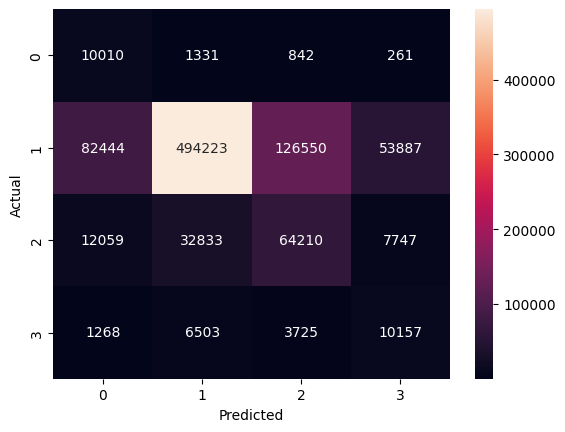

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Eval on test set:

y_test_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# comparing models:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print(classification_report(y_val, lr.predict(X_val)))

C:\Users\austi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.04      0.00      0.00     12444
           2       0.83      1.00      0.91    757104
           3       0.00      0.00      0.00    116849
           4       0.02      0.00      0.00     21653

    accuracy                           0.83    908050
   macro avg       0.22      0.25      0.23    908050
weighted avg       0.70      0.83      0.76    908050



C:\Users\austi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\austi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\austi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
## Permutation importance. This measures true performance against feature drops

frobm sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(result.importances_mean, index=X.columns)
print(perm_importance.sort_values(ascending=False).head(15))